In [2]:
import pandas as pd
df = pd.read_csv("/Users/piyumiwijesirigunawardana/PYTHON projects/2/2.csv")

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
df.shape

(1338, 7)

In [7]:
df.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [10]:
df.describe(include='all')

,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


In [11]:
df.groupby("smoker")["charges"].mean().reset_index()

,smoker,charges
0,no,8434.268298
1,yes,32050.231832


In [14]:
print(df["age"].corr(df["charges"]))
print(df["bmi"].corr(df["charges"]))


0.29900819333064765
0.1983409688336289


In [16]:
smoker = df[df["smoker"] == "yes"]
non_smoker = df[df["smoker"] == "no"]
print(smoker["age"].corr(smoker["charges"]))
print(non_smoker["age"].corr(non_smoker["charges"]))

0.3682244437307778
0.6279467837664195


In [17]:
smoker = df[df["smoker"] == "yes"]
non_smoker = df[df["smoker"] == "no"]
print(smoker["bmi"].corr(smoker["charges"]))
print(non_smoker["bmi"].corr(non_smoker["charges"]))

0.8064806070155406
0.08403654312833271


In [29]:

smoker = df[df["smoker"] == "yes"]
print(smoker["bmi"].max())
print(smoker["bmi"].median())

smoker["bmi_level"] = pd.cut(smoker["bmi"], bins=[0,30.5,52.58], labels= ["low", "high"])
print(smoker.groupby("bmi_level")["charges"].mean().reset_index())

52.58
30.447499999999998
  bmi_level       charges
0       low  22572.981897
1      high  41808.289172


In [31]:
print(non_smoker["bmi"].max())
print(non_smoker["bmi"].median())

non_smoker["bmi_level"] = pd.cut(non_smoker["bmi"], bins=[0,30.3525,54], labels= ["low", "high"])
print(non_smoker.groupby("bmi_level")["charges"].mean().reset_index())

53.13
30.3525
  bmi_level      charges
0       low  7975.913159
1      high  8892.623437


In [34]:
print(df.groupby("sex")["charges"].mean())

sex
female    12569.578844
male      13956.751178
Name: charges, dtype: float64


In [36]:
female = df[df["sex"]=="female"]
male = df[df["sex"]=="male"]

female_smokers = female[female["smoker"] == "yes"]
male_smokers = male[male["smoker"] == "yes"]

print(female_smokers["charges"].mean())
print(male_smokers["charges"].mean())

30678.996276260867
33042.00597528303


In [38]:
print(len(female_smokers))
print(len(male_smokers))

115
159


In [39]:
df.pivot_table(values="charges", index="region", columns="smoker", aggfunc="mean")

smoker,no,yes
region,,
northeast,9165.531672,29673.536473
northwest,8556.463715,30192.003182
southeast,8032.216309,34844.996824
southwest,8019.284513,32269.063494


In [41]:
print(df["children"].corr(df["charges"]))

0.0679982268479048


In [42]:
smoker = df[df["smoker"] == "yes"]
non_smoker = df[df["smoker"] == "no"]
print(smoker["children"].corr(smoker["charges"]))
print(non_smoker["children"].corr(non_smoker["charges"]))

0.0359450058126859
0.13892870453542203


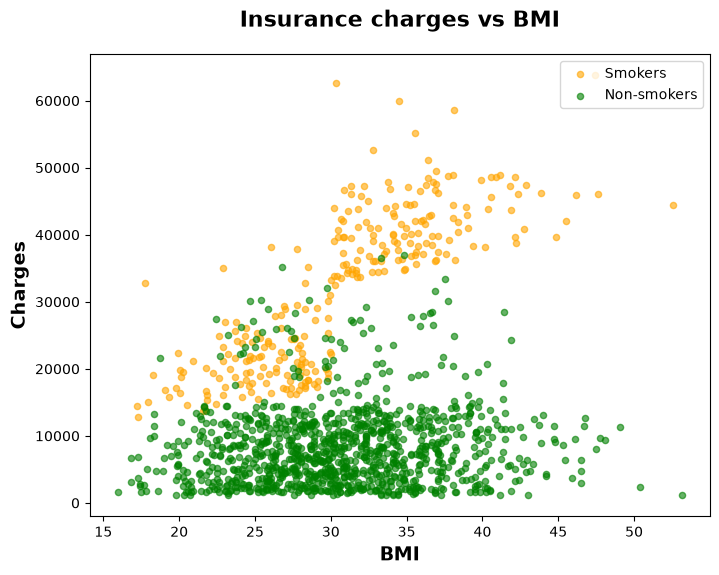

In [53]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.scatter(smoker["bmi"], smoker["charges"], color = "orange", label="Smokers", s=20, alpha=0.6)
plt.scatter(non_smoker["bmi"], non_smoker["charges"], color = "green", label="Non-smokers",s=20, alpha=0.6)
plt.xlabel("BMI", fontsize=14, fontweight="bold")
plt.ylabel("Charges", fontsize=14, fontweight="bold")
plt.legend(loc='upper right')
plt.title('Insurance charges vs BMI', fontsize=16, fontweight='bold', pad=20)
plt.show()

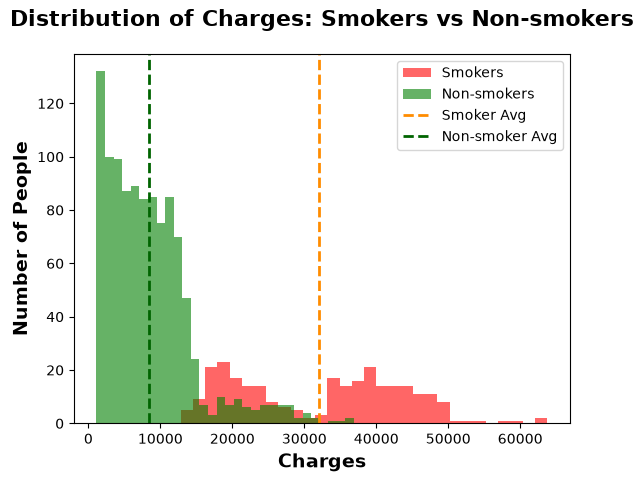

In [55]:
plt.hist(smoker["charges"], bins=30, alpha=0.6, label="Smokers", color="red")
plt.hist(non_smoker["charges"], bins=30, alpha=0.6, label="Non-smokers", color="green")

plt.axvline(smoker["charges"].mean(), color="darkorange", linestyle="--", linewidth=2, label="Smoker Avg")
plt.axvline(non_smoker["charges"].mean(), color="darkgreen", linestyle="--", linewidth=2, label="Non-smoker Avg")

plt.xlabel("Charges", fontsize=14, fontweight="bold")
plt.ylabel("Number of People", fontsize=14, fontweight="bold")
plt.title("Distribution of Charges: Smokers vs Non-smokers", fontsize=16, fontweight="bold", pad=20)
plt.legend(loc="upper right")
plt.show()